In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dolfinx import mesh, fem, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
from mpi4py import MPI
import ufl
from petsc4py import PETSc
from my_functions import *
from visualization_fct import *

In [2]:
# Define geometry
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
slope = (P1[1]-P0[1])/(P1[0]-P0[0])

nx = nz = 10

# Generate mesh from corner points
domain = create_quad_domain(MPI.COMM_WORLD, nx, nz, P0, P1, P2, P3, celltype=mesh.CellType.quadrilateral)

# Initialize functionspace, test function, coordinates
V = fem.functionspace(domain, ("CG", 1))
v = ufl.TestFunction(V)
x = ufl.SpatialCoordinate(domain)

In [3]:
# Boundary condition locators
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)

def top(x):
    return np.isclose(x[1], slope*x[0]+P3[1])

# Dirichlet boundary
def dirichlet(x):
    return -x[1]
dofs_D = fem.locate_dofs_geometrical(V, on_dirichlet)
u_D = fem.Function(V)
u_D.interpolate(dirichlet)
bc = fem.dirichletbc(u_D, dofs_D)

# Inflow (Neumann) boundary
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology) 
facets_on_top = mesh.locate_entities(domain, fdim, top)
facets_not_top = np.setdiff1d(boundary_facets, facets_on_top)
# Mark facets belonging to inflow boundary with 1
facet_markers = np.zeros_like(boundary_facets)
facet_markers[:len(facets_on_top)] = 1
facet_indices = np.hstack([facets_on_top, facets_not_top])
sorted_facets = np.argsort(facet_indices)
# Create meshtags for facets (marker = 1 for inflow boundary)
facet_tags = mesh.meshtags(domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]) 
# Create custom integration measure for inflow boundary
ds = ufl.Measure("ds", domain, subdomain_data=facet_tags)
# Recharge
c_in = fem.Constant(domain, PETSc.ScalarType(2e-9))
inflow = - v * c_in * ds(1)

In [4]:
# Define constants (silt)
alpha = 1.6
N = 1.37
theta_r = 0.034
theta_s = 0.46
Ks = 6.94e-7

# van Genuchten
def S_e(h_c):
    return ufl.conditional(h_c < 0, (1 + (- alpha * h_c)**N)**((1 - N) / N), 1)
def theta(Se):
    return theta_r + (theta_s - theta_r)*Se
def k_rel(Se):
    m = 1 - 1/N
    return ufl.conditional(Se < 1 - 1e-7, ufl.sqrt(Se) * (1 - (1 - Se**(1/m))**m)**2 , 1)

In [5]:
# Time discretization
t = 0.0 # start time [s]
T = 24*60*60 # end time [s]
delta_t = 7 # time step [s]

In [6]:
# Variational formulation
h_c_old = fem.Function(V)
h_c_old.name = "h_c_old"
h_c_old.x.array[:] = -1e-2*np.ones_like(h_c_old.x.array) # initial condition close to saturation

h_c_new = fem.Function(V)
h_c_new.x.array[:] = h_c_old.x.array

z = x[1]

petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "none",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-4,
    "snes_monitor": None,
    "snes_maxit": 20,
    "ksp_error_if_not_converged": True,
    "ksp_type": "gmres",
    "ksp_rtol": 1e-4,
    "ksp_monitor": None,
    "pc_type": "hypre",
    "pc_hypre_type": "boomeramg",
    "pc_hypre_boomeramg_max_iter": 1,
    "pc_hypre_boomeramg_cycle_type": "v",
}

while t <= T:
    t += delta_t

    # Initial guess for Newton
    h_c_new.x.array[:] = h_c_old.x.array

    # Weak formulation
    F = (theta(S_e(h_c_new)) - theta(S_e(h_c_old))) / delta_t * v * ufl.dx
    F += ufl.dot(ufl.grad(v), Ks * k_rel(S_e(h_c_new)) * ufl.grad(z + h_c_new)) * ufl.dx
    F += inflow
    problem = NonlinearProblem(
        F,
        h_c_new,
        bcs=[bc],
        petsc_options=petsc_options,
        petsc_options_prefix="richards",
    )
    h_c_new = problem.solve()
    converged = problem.solver.getConvergedReason()
    num_iter = problem.solver.getIterationNumber()
    assert converged > 0, f"Solver did not converge, got {converged}."
    print(
        f"Solver converged after {num_iter} iterations with converged reason {converged}."
    )

    # adaptive time stepping:
    if num_iter > 10 and delta_t > 1e-1:
        delta_t *= 0.5
    if num_iter < 3:
        delta_t *= 1.2

    # update old solution
    h_c_old.x.array[:] = h_c_new.x.array
    

  0 SNES Function norm 1.305526732312e+00
    Residual norms for richards solve.
    0 KSP Residual norm 1.348091239193e+00
    1 KSP Residual norm 3.362122721693e-02
    2 KSP Residual norm 2.505730154921e-03
    3 KSP Residual norm 2.285848947250e-04
    4 KSP Residual norm 2.509540989135e-05
  1 SNES Function norm 2.566838412664e-04
    Residual norms for richards solve.
    0 KSP Residual norm 1.818300769690e-01
    1 KSP Residual norm 7.023798513748e-02
    2 KSP Residual norm 3.196611489535e-03
    3 KSP Residual norm 4.641394449483e-04
    4 KSP Residual norm 6.452456236942e-05
    5 KSP Residual norm 8.718273783521e-06
  2 SNES Function norm 4.317704743193e-05
Solver converged after 2 iterations with converged reason 3.
  0 SNES Function norm 1.203515650652e-06
    Residual norms for richards solve.
    0 KSP Residual norm 4.580396182513e-03
    1 KSP Residual norm 2.997809454869e-04
    2 KSP Residual norm 4.311441052544e-05
    3 KSP Residual norm 5.537727702268e-06
    4 KSP

    Residual norms for richards solve.
    0 KSP Residual norm 4.300235471783e-04
    1 KSP Residual norm 3.430675428216e-05
    2 KSP Residual norm 1.259138317573e-06
    3 KSP Residual norm 2.244372656504e-07
    4 KSP Residual norm 2.445101539717e-08
  2 SNES Function norm 7.535081035990e-10
    Residual norms for richards solve.
    0 KSP Residual norm 1.009348000113e-05
    1 KSP Residual norm 3.014370523860e-06
    2 KSP Residual norm 6.677416274937e-08
    3 KSP Residual norm 8.546859597433e-09
    4 KSP Residual norm 9.940560957977e-10
  3 SNES Function norm 4.705130495806e-11
Solver converged after 3 iterations with converged reason 2.
  0 SNES Function norm 1.112185528263e-06
    Residual norms for richards solve.
    0 KSP Residual norm 9.567987989566e-03
    1 KSP Residual norm 5.644407897139e-04
    2 KSP Residual norm 5.802344360347e-05
    3 KSP Residual norm 5.499562525507e-06
    4 KSP Residual norm 7.172774781827e-07
  1 SNES Function norm 2.390561255323e-08
    Resid

2026-05-22 14:56:52.275 (  16.243s) [    712450741600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card2: Permission denied

2026-05-22 14:56:52.298 (  16.266s) [    712450741600] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x5debb6ae27f0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card2: Permission denied

2026-05-22 14:56:52.319 (  16.287s) [    712450741600] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x5debb6ae8700): EGL device index: 0 could not be initialized.

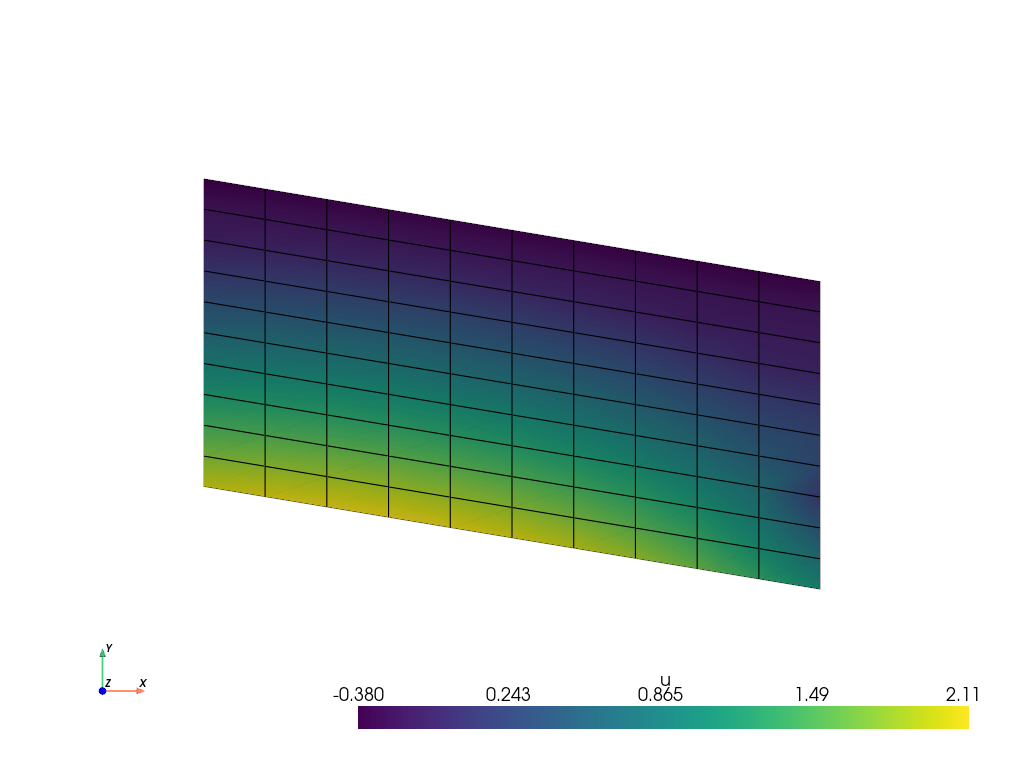

In [7]:
plotScalarFunction(V, h_c_new)

In [7]:
# Evaluate solution
n = 10
grid, x_grid, z_grid = get_grid(P0, P1, P2, P3, n)
pressure_head = eval_fct_on_grid(grid, h_c_new, domain).reshape((n,n))
h_tot = pressure_head + z_grid
h_c = pressure_head * (pressure_head <= 0)
def S_e1(h_c):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = theta_r + (theta_s - theta_r)*S_e1(h_c.flatten()).reshape((n,n))

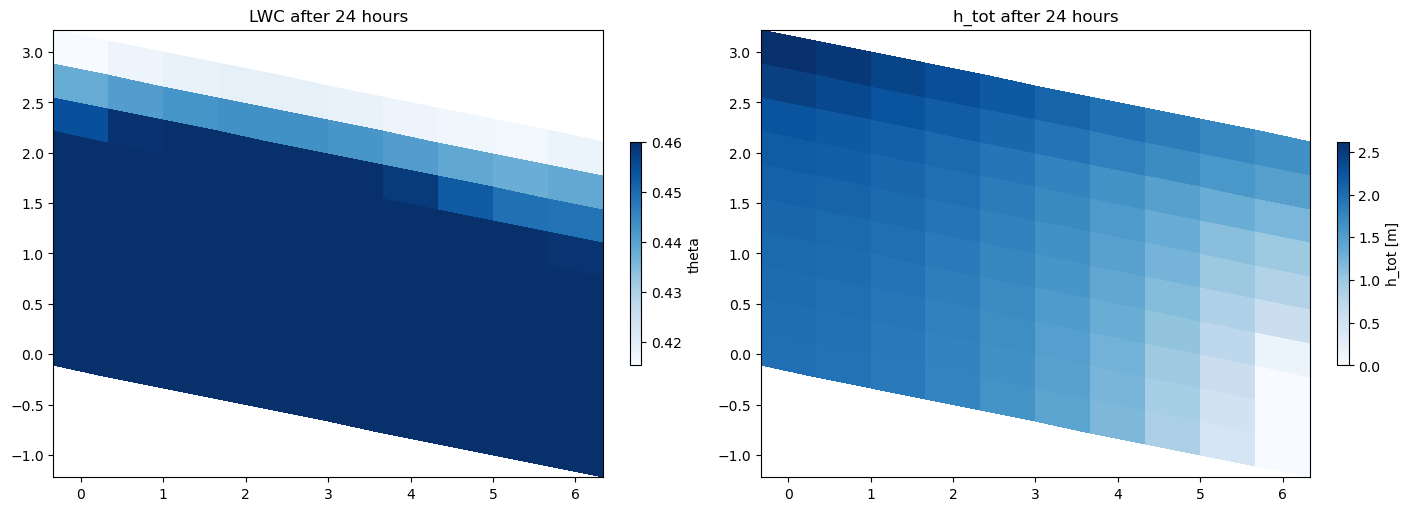

In [20]:
# Plot solution

fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_grid, z_grid, theta_tot, cmap="Blues")
ax[0].set_title(f"LWC after {T/3600:.0f} hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[1].pcolormesh(x_grid, z_grid, h_tot, cmap="Blues")
ax[1].set_title(f"h_tot after {T/3600:.0f} hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("h_tot [m]")

## Compare to Annes data

In [11]:
import pickle

# open pickle file and load
with open("Test_Annika.pkl", "rb") as f:
    data = pickle.load(f)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [14]:
anne_x = data["X_plot"][23]
anne_z = data["Z_plot"][23]
anne_theta = data["theta_l_total"][23]
anne_h_tot = data["h_total"][23]
anne_h_c = data["h_c_total"][23]

In [18]:
anne_h_c

Array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0